# Análisis del benchmark de vectorizaciones esparzas sobre documentos legales

Este notebook analiza el resultado de un benchmark que compara **16 métodos de vectorización esparza** (BM25, TF-IDF, SPLADE con tres pipelines de preprocesamiento, sus fusiones RRF, y un baseline) sobre **31 queries legales**. Cada método trae top-10 chunks por query, y un LLM juez asignó un grado de relevancia 0–3 a cada chunk recuperado.

El análisis va de lo más general a lo más particular en 5 niveles:

- **Nivel 0** — Sanity checks del juez y las queries
- **Nivel 1** — Tabla maestra: ranking global de métodos
- **Nivel 2** — Distribuciones y dispersión
- **Nivel 3** — Comparación entre familias
- **Nivel 4** — Análisis cualitativo del ganador



In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# ── Parámetros configurables ────────────────────────────────────────
EXCEL_PATH = 'benchmark_results.xlsx'   # ajustar si está en otra ruta
REL_THR    = 2          # grade mínimo para considerar un chunk "relevante" (hit / MRR)
K_MAIN     = 10         # k principal para nDCG y mean_grade


In [4]:
from google.colab import files
uploaded = files.upload()


Saving benchmark_results.xlsx to benchmark_results.xlsx


In [5]:
# Cargar todas las hojas del Excel
sheets = pd.read_excel(EXCEL_PATH, sheet_name=None)
results    = sheets['results']      # query × método × rank (con relevance_grade)
judgments  = sheets['judgments']    # query × chunk juzgado
queries    = sheets['queries']      # catálogo de queries
chunks_df  = sheets['chunks']       # metadata + contenido de chunks

print(f"results:   {len(results):>6,} filas   (query × método × rank)")
print(f"judgments: {len(judgments):>6,} filas   (query × chunk)")
print(f"queries:   {len(queries):>6,} filas")
print(f"chunks:    {len(chunks_df):>6,} filas")
print()
print(f"Queries: {results['query_id'].nunique()}, métodos: {results['method'].nunique()}")


results:    4,622 filas   (query × método × rank)
judgments:  1,699 filas   (query × chunk)
queries:       31 filas
chunks:     1,200 filas

Queries: 31, métodos: 16


---
## Nivel 0 — Sanity checks

Antes de declarar ganadores hay que verificar dos cosas:

1. **¿El juez (LLM) está sesgado?** Si pone casi todo en grade 2-3 o casi todo en 0, las métricas pierden poder discriminativo.
2. **¿Hay queries no-discriminantes?** Una query donde todos los chunks valen 3 (o todos 0) no separa métodos buenos de malos. Si hay muchas, hay que pensar si filtrarlas.


In [6]:
# 1) Distribución global de grades del juez
grade_dist = judgments['relevance_grade'].value_counts().sort_index()
grade_pct  = (grade_dist / grade_dist.sum() * 100).round(1)
sanity_1 = pd.DataFrame({'count': grade_dist, '%': grade_pct})
sanity_1.index.name = 'grade'
print("Distribución global de grades (sobre todos los juicios):")
print(sanity_1)


Distribución global de grades (sobre todos los juicios):
       count     %
grade             
0        553  32.5
1        316  18.6
2        586  34.5
3        244  14.4


In [7]:
# 2) Queries no-discriminantes: ¿hay queries donde el juez puso casi todo igual?
per_query = (judgments.groupby('query_id')['relevance_grade']
             .agg(['mean', 'std', 'min', 'max', 'count'])
             .round(2))
per_query['rango'] = per_query['max'] - per_query['min']

# Una query es "no-discriminante" si tiene rango chico o std muy baja
sospechosas = per_query[(per_query['rango'] <= 1) | (per_query['std'] < 0.5)]
print(f"Queries posiblemente no-discriminantes: {len(sospechosas)} de {len(per_query)}")
if len(sospechosas) > 0:
    print()
    display(sospechosas.merge(queries[['query_id','query_text']], on='query_id'))


Queries posiblemente no-discriminantes: 0 de 31


---
## Nivel 1 — Tabla maestra: ranking global de métodos

Esta es la foto principal del benchmark. Una fila por método, ordenada por **nDCG@10** (métrica titular).

### Métricas incluidas

| Métrica | Qué mide |
|---|---|
| `mean_grade_top3/5/10` | Promedio simple de los grades en las primeras 3 / 5 / 10 posiciones. La más intuitiva pero **no penaliza el orden**. |
| `hit@3` | Fracción de queries donde aparece al menos 1 chunk relevante (grade ≥ 2) en el top-3. |
| `hit@10` | Ídem, pero mirando el top-10 completo. |
| `MRR` | Mean Reciprocal Rank — qué tan arriba aparece el **primer** relevante. Ver explicación en celda siguiente. |
| `nDCG@10` | Normalized Discounted Cumulative Gain — **la métrica estándar de IR** para grades graduados. Ver explicación abajo. |


### Cómo se calculan las métricas

**MRR (Mean Reciprocal Rank).** Para cada query mira en qué posición aparece el primer chunk con grade ≥ 2 y toma `1 / posición`. Después promedia sobre todas las queries.
- Primer relevante en posición 1 → 1.00
- Primer relevante en posición 2 → 0.50
- Primer relevante en posición 5 → 0.20
- Ningún relevante en top-10 → 0.00

MRR responde *"¿qué tan rápido el método pone algo útil arriba?"*. Es ciego a si hay 1 relevante o 10 — solo le importa el primero.

**nDCG@10 (normalized Discounted Cumulative Gain).** Combina dos ideas:

1. **DCG (suma descontada)**: suma los grades del top-10 **descontando por posición**:
   $$DCG = \sum_{i=1}^{10} \frac{2^{grade_i} - 1}{\log_2(i+1)}$$
   El divisor `log2(i+1)` hace que un grade alto en posición 1 valga mucho y el mismo grade en posición 10 valga poco. La fórmula `2^grade - 1` agranda la diferencia entre grade 2 y grade 3 (un "muy relevante" pesa más del doble que un "relevante").

2. **IDCG (DCG ideal)**: lo mismo pero ordenando perfecto — agarro **todos los chunks juzgados** para esta query, los ordeno por grade descendente, agarro los primeros 10 y calculo su DCG. Es el techo teórico.

3. **nDCG = DCG / IDCG**. Queda entre 0 y 1, donde 1 = ranking perfecto. Permite comparar queries con distinta cantidad de chunks relevantes disponibles.


In [8]:
# Funciones auxiliares de métricas IR

def dcg(grades):
    """DCG sobre una lista ordenada de grades (posición 1 primero).
    Fórmula: sum_i (2^grade_i - 1) / log2(i + 1)"""
    grades = np.asarray(grades, dtype=float)
    if len(grades) == 0:
        return 0.0
    # log2(2), log2(3), log2(4), ... — la posición i (1-indexed) usa log2(i+1)
    discounts = np.log2(np.arange(2, len(grades) + 2))
    return float(np.sum((2**grades - 1) / discounts))


def ndcg_at_k(method_grades_in_order, all_judged_grades_for_query, k=10):
    """nDCG@k.
    - method_grades_in_order: grades del top-k devueltos por el método, en el orden del ranking
    - all_judged_grades_for_query: todos los grades juzgados para esa query (para el ideal)
    """
    actual = list(method_grades_in_order)[:k]
    ideal  = sorted(all_judged_grades_for_query, reverse=True)[:k]
    idcg = dcg(ideal)
    return dcg(actual) / idcg if idcg > 0 else 0.0


def reciprocal_rank(grades_in_order, thr=REL_THR):
    """Posición del primer relevante (grade>=thr) — devuelve 1/pos, o 0 si no aparece."""
    for i, g in enumerate(grades_in_order, start=1):
        if g >= thr:
            return 1.0 / i
    return 0.0


def hit_at_k(grades_in_order, k, thr=REL_THR):
    """1 si hay al menos un grade>=thr en las primeras k posiciones, 0 si no."""
    return int(any(g >= thr for g in grades_in_order[:k]))


In [9]:
# Construir tabla maestra: una fila por (query, método) con todas las métricas,
# después promediamos por método.

# Para el IDCG necesitamos los grades juzgados por query
judged_by_query = judgments.groupby('query_id')['relevance_grade'].apply(list).to_dict()

per_qm_rows = []
for (qid, method), grp in results.groupby(['query_id', 'method']):
    grp_sorted = grp.sort_values('rank')
    grades = grp_sorted['relevance_grade'].fillna(0).tolist()
    ideal_grades = judged_by_query.get(qid, [])

    per_qm_rows.append({
        'query_id':  qid,
        'method':    method,
        'mean_grade_top3':  np.mean(grades[:3]) if grades else np.nan,
        'mean_grade_top5':  np.mean(grades[:5]) if grades else np.nan,
        'mean_grade_top10': np.mean(grades[:K_MAIN]) if grades else np.nan,
        'hit@3':            hit_at_k(grades, 3, REL_THR),
        'hit@10':           hit_at_k(grades, 10, REL_THR),
        'MRR':              reciprocal_rank(grades, REL_THR),
        'nDCG@10':          ndcg_at_k(grades, ideal_grades, K_MAIN),
    })

per_qm = pd.DataFrame(per_qm_rows)
print(f"per_qm shape: {per_qm.shape}  (debería ser {results['query_id'].nunique()} queries × {results['method'].nunique()} métodos)")
per_qm.head()


per_qm shape: (496, 9)  (debería ser 31 queries × 16 métodos)


,query_id,method,mean_grade_top3,mean_grade_top5,mean_grade_top10,hit@3,hit@10,MRR,nDCG@10
0,q000,baseline_qdrant_bm25,3.000000,2.6,2.3,1,1,1.0,0.696571
1,q000,p1_bm25,2.666667,2.4,2.3,1,1,1.0,0.675610
2,q000,p1_splade,2.333333,2.6,2.5,1,1,1.0,0.733186
3,q000,p1_tfidf,2.333333,2.2,2.0,1,1,1.0,0.522964
4,q000,p2_bm25,2.666667,2.4,2.1,1,1,1.0,0.631878


In [10]:
# Tabla maestra: promediar todas las métricas por método

master = (per_qm.drop(columns=['query_id'])
          .groupby('method')
          .mean(numeric_only=True)
          .round(4)
          .sort_values('nDCG@10', ascending=False))

print("TABLA MAESTRA — ranking de métodos por nDCG@10")
print("=" * 80)
master


TABLA MAESTRA — ranking de métodos por nDCG@10


,mean_grade_top3,mean_grade_top5,mean_grade_top10,hit@3,hit@10,MRR,nDCG@10
method,,,,,,,
p3_bm25,2.1828,2.1484,2.0548,0.9677,0.9677,0.9301,0.6925
rrf_p3_bm25,2.2581,2.2129,2.1184,0.9355,0.9677,0.8952,0.6702
rrf_p2_bm25,2.2796,2.2258,2.1004,0.9677,0.9677,0.9032,0.6626
p1_bm25,2.1290,2.1290,2.0032,0.9677,1.0000,0.8804,0.6538
p2_bm25,2.1613,2.0645,1.9613,0.9677,0.9677,0.9032,0.6520
rrf_p1_bm25,2.1613,2.0839,2.0288,0.9032,0.9677,0.8444,0.6236
rrf_p3_tfidf,2.1828,2.0387,1.9189,0.9032,0.9355,0.8629,0.6088
rrf_baseline_qdrant_bm25,2.0753,2.0065,1.9462,0.8710,0.9355,0.8487,0.5876
rrf_p1_splade,2.1935,2.0516,1.9317,0.9355,0.9677,0.9097,0.5855


---
## Nivel 2 — Distribuciones y dispersión

El promedio no es todo. Un método con nDCG@10 medio de 0.85 pero alta varianza puede ser peor que uno con 0.83 estable.

**Cómo leer el boxplot:**
- La caja muestra el 50% central de las queries (de Q1=percentil 25 a Q3=percentil 75).
- La línea adentro de la caja es la **mediana** (percentil 50).
- Los "bigotes" llegan hasta el último valor no-outlier (1.5×IQR de los cuartiles).
- Puntos sueltos son outliers — queries especialmente fáciles o difíciles para ese método.
- **Caja chica = método consistente**. Caja grande = el método depende mucho de la query.


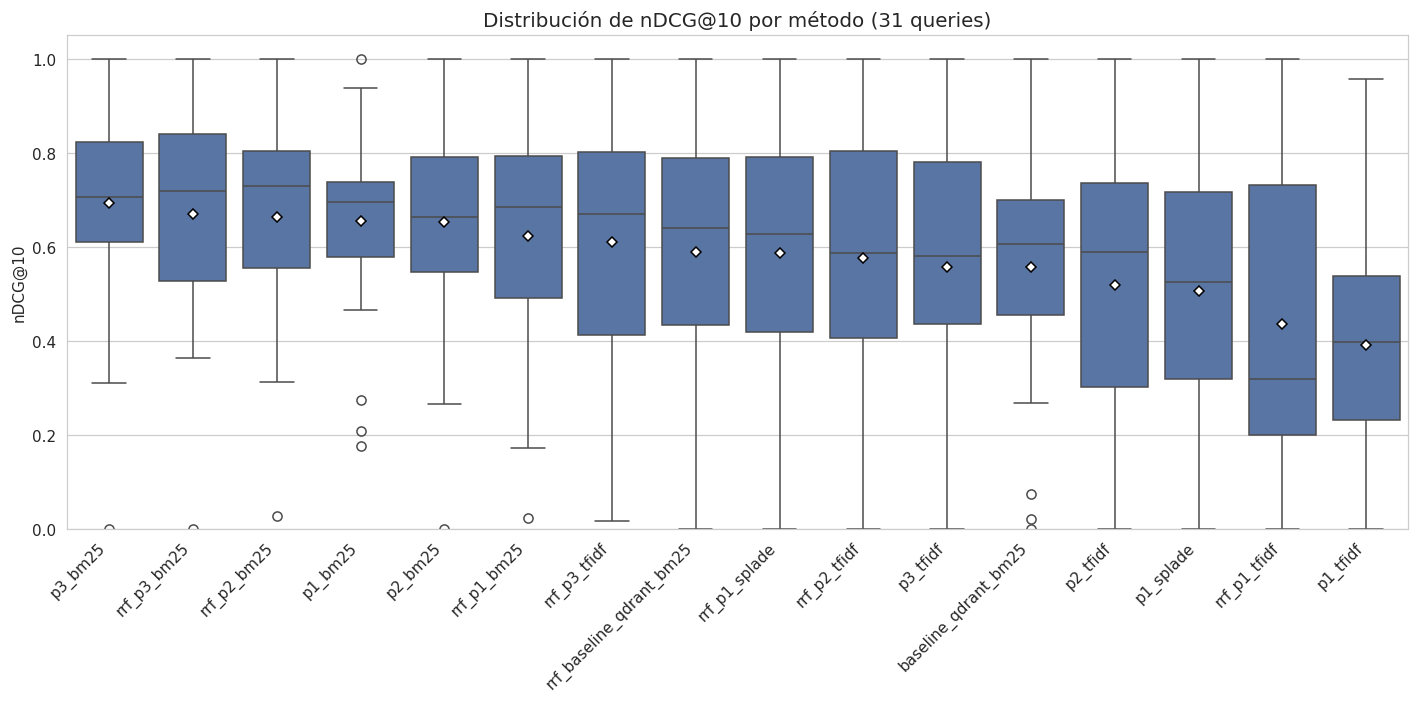

In [11]:
# Boxplot de nDCG@10 por método — ordenados por nDCG medio descendente
method_order = master.index.tolist()

fig, ax = plt.subplots(figsize=(13, 6.5))
sns.boxplot(
    data=per_qm,
    x='method', y='nDCG@10',
    order=method_order,
    ax=ax,
    color='#4C72B0',
    showmeans=True,
    meanprops={'marker':'D', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':5},
)
ax.set_title('Distribución de nDCG@10 por método (31 queries)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('nDCG@10')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('ndcg_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# Tabla complementaria: mediana, desvío estándar, rango
disp = (per_qm.groupby('method')['nDCG@10']
        .agg(mediana='median', std='std', minimo='min', maximo='max')
        .round(3))
disp['rango'] = (disp['maximo'] - disp['minimo']).round(3)
disp = disp.loc[method_order]
print("Estabilidad de nDCG@10 por método (orden = ranking de la tabla maestra)")
print("=" * 80)
disp


Estabilidad de nDCG@10 por método (orden = ranking de la tabla maestra)


,mediana,std,minimo,maximo,rango
method,,,,,
p3_bm25,0.706,0.198,0.000,1.000,1.000
rrf_p3_bm25,0.717,0.212,0.000,1.000,1.000
rrf_p2_bm25,0.730,0.219,0.027,1.000,0.973
p1_bm25,0.694,0.194,0.176,1.000,0.824
p2_bm25,0.662,0.211,0.000,1.000,1.000
rrf_p1_bm25,0.684,0.244,0.023,1.000,0.977
rrf_p3_tfidf,0.668,0.267,0.016,1.000,0.984
rrf_baseline_qdrant_bm25,0.639,0.271,0.000,1.000,1.000
rrf_p1_splade,0.626,0.251,0.000,1.000,1.000


---
## Nivel 2.5 — Significancia estadística (Wilcoxon pareado)

La tabla maestra muestra a `p3_bm25` arriba (nDCG@10 ≈ 0.693) seguido de cerca por otros BM25 (`rrf_p3_bm25` 0.670, `p1_bm25` 0.654, `p2_bm25` 0.652). Pero la desviación estándar de nDCG entre queries es ≈ 0.20 — **mucho más grande que esas diferencias**. La pregunta clave: *¿el ganador es realmente mejor, o la diferencia es ruido entre queries?*

**Por qué un test pareado.** Comparar dos promedios sueltos ignora que algunas queries son fáciles para *todos* los métodos y otras difíciles para *todos*. El test **pareado** compara los dos métodos **query por query** (misma query, dos nDCG), y mira la distribución de las *diferencias*. Así se cancela el ruido de "query fácil / query difícil".

**Por qué Wilcoxon y no t-test.** El Wilcoxon signed-rank es no-paramétrico: no asume que las diferencias sean normales. Con n=31 queries y una métrica acotada en [0,1] que no es normal, es la elección estándar en la literatura de Information Retrieval.

**Corrección por comparaciones múltiples (Holm).** Como comparamos al ganador contra varios contendientes a la vez, la probabilidad de un falso positivo se infla. La corrección de Holm ajusta los p-valores hacia arriba para controlar eso.

**Cómo leer el resultado:**
- `p < 0.05` → el ganador es significativamente mejor que ese contendiente. Se puede escribir la recomendación con firmeza.
- `p ≥ 0.05` → no hay evidencia de diferencia real. La afirmación honesta es *"gana la familia BM25; el pipeline específico es de segundo orden"*.


In [ ]:
from scipy.stats import wilcoxon

# Contendientes a comparar contra el ganador (editar si cambia el ranking)
CONTENDERS = ['rrf_p3_bm25', 'p1_bm25', 'p2_bm25']
WINNER = master.index[0]

# Matriz query × método de nDCG@10 (filas alineadas por query → pareado)
ndcg_wide = per_qm.pivot(index='query_id', columns='method', values='nDCG@10')

rows = []
for opp in CONTENDERS:
    diff = ndcg_wide[WINNER] - ndcg_wide[opp]
    n_better = int((diff > 0).sum())   # queries donde gana el winner
    n_worse  = int((diff < 0).sum())   # queries donde pierde
    n_tie    = int((diff == 0).sum())

    # Wilcoxon signed-rank (one-sided: winner > opponent). zero_method='wilcox' descarta empates.
    try:
        stat, p = wilcoxon(ndcg_wide[WINNER], ndcg_wide[opp],
                           alternative='greater', zero_method='wilcox')
    except ValueError:
        stat, p = float('nan'), 1.0  # todas las diferencias son 0

    rows.append({
        'contendiente': opp,
        'nDCG_winner':  round(ndcg_wide[WINNER].mean(), 4),
        'nDCG_opp':     round(ndcg_wide[opp].mean(), 4),
        'delta_medio':  round(diff.mean(), 4),
        'gana/pierde/empata': f"{n_better}/{n_worse}/{n_tie}",
        'p_raw':        p,
    })

wilcox = pd.DataFrame(rows)

# Corrección de Holm para comparaciones múltiples
order = wilcox['p_raw'].argsort().values
m = len(wilcox)
p_holm = [None] * m
running_max = 0.0
for rank, idx in enumerate(order):
    adj = min((m - rank) * wilcox['p_raw'].iloc[idx], 1.0)
    running_max = max(running_max, adj)   # Holm es monótono
    p_holm[idx] = round(running_max, 4)
wilcox['p_holm'] = p_holm
wilcox['significativo (α=0.05)'] = wilcox['p_holm'] < 0.05

print(f"Test de Wilcoxon pareado, one-sided:  '{WINNER}' > contendiente")
print(f"(n = {ndcg_wide.shape[0]} queries, métrica = nDCG@10)")
print("=" * 80)
wilcox

In [ ]:
# Veredicto automático en texto
n_sig = int(wilcox['significativo (α=0.05)'].sum())
print("VEREDICTO")
print("=" * 80)
if n_sig == len(wilcox):
    print(f"'{WINNER}' es significativamente mejor que TODOS sus contendientes (p_holm < 0.05).")
    print("→ Se puede escribir la recomendación con firmeza: este pipeline específico gana.")
elif n_sig == 0:
    print(f"NINGUNA diferencia con '{WINNER}' es significativa (todos los p_holm >= 0.05).")
    print("→ Afirmación honesta: gana la FAMILIA BM25; el pipeline específico es de segundo orden.")
else:
    sig = wilcox.loc[wilcox['significativo (α=0.05)'], 'contendiente'].tolist()
    nosig = wilcox.loc[~wilcox['significativo (α=0.05)'], 'contendiente'].tolist()
    print(f"'{WINNER}' es significativamente mejor que: {sig}")
    print(f"Pero NO se distingue de: {nosig}")
    print("→ Recomendación matizada: el ganador supera a algunos contendientes, pero")
    print(f"  empata estadísticamente con {nosig} dentro de la familia BM25.")

---
## Nivel 3 — Comparación entre familias

Los 16 métodos no son independientes — hay grupos naturales:

- **Algoritmo base**: BM25, TF-IDF, SPLADE.
- **Pipeline de preprocesamiento**: p1, p2, p3 (más el baseline de Qdrant).
- **Fusión**: puro vs `rrf_*` (Reciprocal Rank Fusion).

El **heatmap** método × query muestra qué métodos se parecen entre sí (filas similares) y qué queries son fáciles o difíciles para todos (columnas uniformes).

Después, una **tabla agregada por familia** responde *"¿cuál grupo es mejor en promedio?"*.


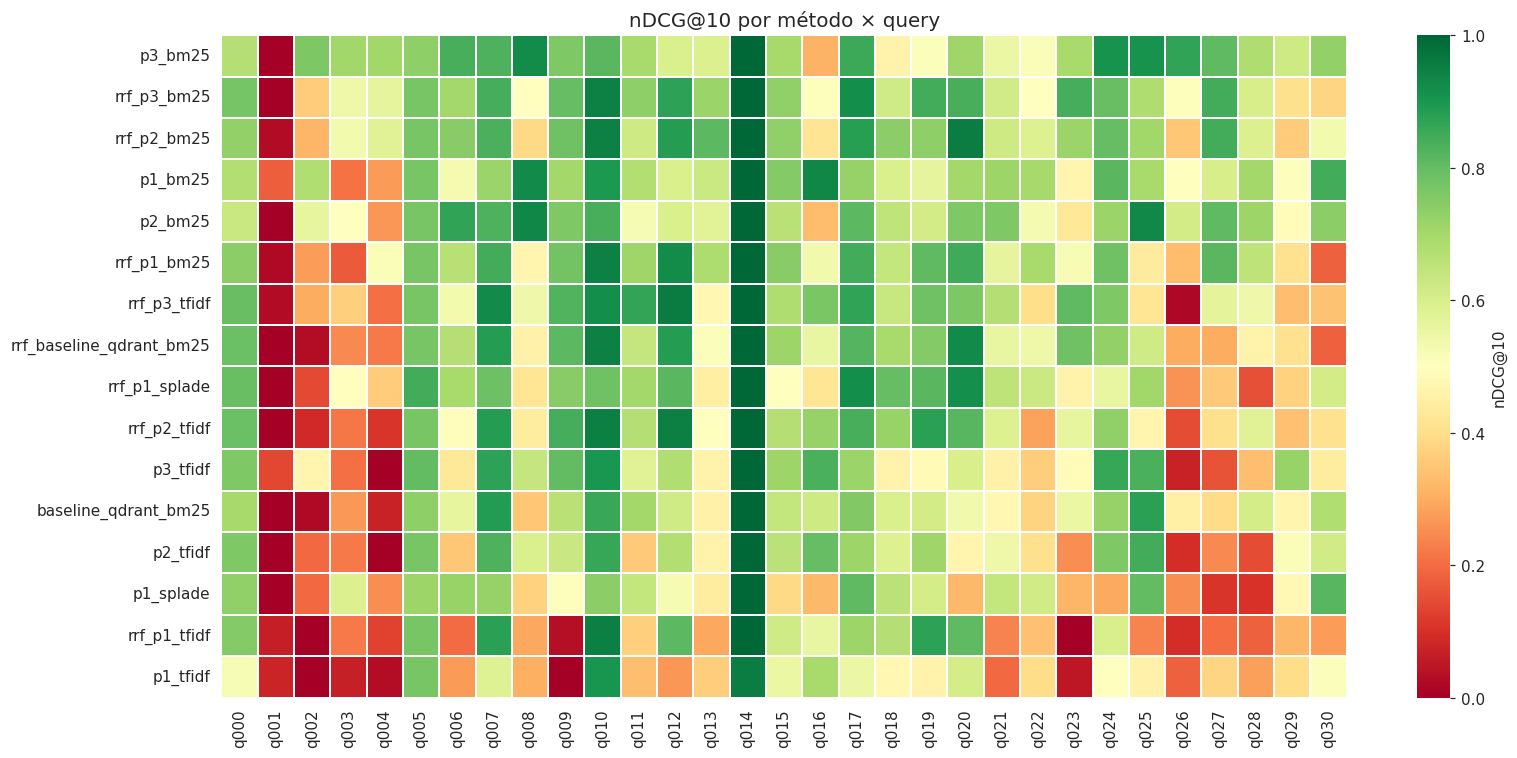

In [13]:
# Heatmap: método × query con nDCG@10
heat = (per_qm.pivot(index='method', columns='query_id', values='nDCG@10')
        .loc[method_order])

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(heat, cmap='RdYlGn', vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'nDCG@10'},
            linewidths=0.3, linecolor='white')
ax.set_title('nDCG@10 por método × query', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('ndcg_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Parser del nombre de método → familia (algoritmo, pipeline, fusión)
def parse_method(m):
    fusion = 'rrf' if m.startswith('rrf_') else 'puro'
    core = m.replace('rrf_', '')
    if 'baseline' in core:
        return pd.Series({'algoritmo': 'bm25', 'pipeline': 'baseline', 'fusion': fusion})
    parts = core.split('_', 1)
    return pd.Series({'algoritmo': parts[1], 'pipeline': parts[0], 'fusion': fusion})

method_meta = pd.DataFrame({'method': per_qm['method'].unique()})
method_meta = pd.concat([method_meta, method_meta['method'].apply(parse_method)], axis=1)

# Unir y agregar
fam = per_qm.merge(method_meta, on='method')

family_summary = (fam.groupby(['algoritmo', 'pipeline', 'fusion'])['nDCG@10']
                  .agg(['mean', 'std', 'count'])
                  .round(3)
                  .sort_values('mean', ascending=False))
print("Agregado por familia (algoritmo × pipeline × fusion)")
print("=" * 80)
family_summary


Agregado por familia (algoritmo × pipeline × fusion)


mean    std  count
algoritmo pipeline fusion                     
bm25      p3       puro    0.693  0.198     31
                   rrf     0.670  0.212     31
          p2       rrf     0.663  0.219     31
          p1       puro    0.654  0.194     31
          p2       puro    0.652  0.211     31
          p1       rrf     0.624  0.244     31
tfidf     p3       rrf     0.609  0.267     31
bm25      baseline rrf     0.588  0.271     31
splade    p1       rrf     0.586  0.251     31
tfidf     p2       rrf     0.577  0.280     31
bm25      baseline puro    0.557  0.241     31
tfidf     p3       puro    0.557  0.264     31
          p2       puro    0.518  0.273     31
splade    p1       puro    0.506  0.248     31
tfidf     p1       rrf     0.435  0.314     31
                   puro    0.391  0.252     31

In [15]:
# Vista compacta: ¿RRF mejora consistentemente? ¿qué pipeline es el mejor?
print("¿La fusión RRF mejora vs el método puro?")
print((fam.groupby(['algoritmo', 'pipeline', 'fusion'])['nDCG@10']
       .mean().unstack('fusion').round(3)
       .assign(diff_rrf_minus_puro=lambda d: (d['rrf'] - d['puro']).round(3))))


¿La fusión RRF mejora vs el método puro?
fusion               puro    rrf  diff_rrf_minus_puro
algoritmo pipeline                                   
bm25      baseline  0.557  0.588                0.031
          p1        0.654  0.624               -0.030
          p2        0.652  0.663                0.011
          p3        0.693  0.670               -0.023
splade    p1        0.506  0.586                0.080
tfidf     p1        0.391  0.435                0.044
          p2        0.518  0.577                0.059
          p3        0.557  0.609                0.052


---
## Nivel 4 — Análisis cualitativo del ganador

Hasta acá tenemos el ranking. Ahora: **¿por qué gana y dónde pierde?**

Estrategia simple:
1. Identificar el método ganador por nDCG@10.
2. Listar las 3 queries donde gana fácil (nDCG más alto) y las 3 donde más sufre (nDCG más bajo).
3. Mirar el texto de esas queries y los chunks que el método trajo, con sus grades.

Esto da los insights cualitativos que después se redactan en el paper.


In [16]:
WINNER = master.index[0]
print(f"Método ganador: {WINNER}")
print(f"nDCG@10 medio: {master.loc[WINNER, 'nDCG@10']:.3f}")

winner_per_q = (per_qm[per_qm['method'] == WINNER]
                .merge(queries[['query_id', 'query_text']], on='query_id')
                .sort_values('nDCG@10'))

print("\nLas 3 queries donde el ganador MÁS SUFRE:")
display(winner_per_q.head(3)[['query_id', 'query_text', 'nDCG@10', 'hit@10', 'mean_grade_top10']])

print("\nLas 3 queries donde el ganador GANA FÁCIL:")
display(winner_per_q.tail(3)[['query_id', 'query_text', 'nDCG@10', 'hit@10', 'mean_grade_top10']])


Método ganador: p3_bm25
nDCG@10 medio: 0.693

Las 3 queries donde el ganador MÁS SUFRE:


,query_id,query_text,nDCG@10,hit@10,mean_grade_top10
1,q001,Obligaciones del arrendador de mantener el inm...,0.000000,0,0.0
16,q016,Devolución del IVA en la venta de inmuebles nu...,0.310083,1,1.5
18,q018,¿Cómo tributa el mayor valor obtenido en la ve...,0.457550,1,1.9



Las 3 queries donde el ganador GANA FÁCIL:


,query_id,query_text,nDCG@10,hit@10,mean_grade_top10
25,q025,Tercería de dominio sobre inmueble embargado e...,0.910143,1,2.4
8,q008,Rescisión de la compraventa de un bien raíz po...,0.925619,1,2.4
14,q014,Avalúo fiscal y reavalúo de condominios acogid...,1.000000,1,2.0


In [17]:
# Inspeccionar el top-5 que trajo el ganador en las 3 queries peores
worst_qids = winner_per_q.head(3)['query_id'].tolist()

for qid in worst_qids:
    qtext = queries.loc[queries['query_id'] == qid, 'query_text'].iloc[0]
    print("=" * 90)
    print(f"{qid}  —  {qtext}")
    print("=" * 90)
    sub = (results[(results['query_id'] == qid) & (results['method'] == WINNER)]
           .sort_values('rank').head(5))
    sub = sub.merge(chunks_df[['chunk_uuid', 'name', 'source']], on='chunk_uuid', how='left')
    for _, r in sub.iterrows():
        print(f"  #{int(r['rank'])}  grade={r['relevance_grade']}  "
              f"{r['source']!s:.30s}  /  {r['name']!s:.45s}")
    print()


q001  —  Obligaciones del arrendador de mantener el inmueble en condiciones habitables
  #1  grade=0  Oficio N°1806 (03/06/2022)  /  Oficio N°1806 (03/06/2022)
  #2  grade=0  Oficio N°1034 (15/04/2019)  /  Oficio N°1034 (15/04/2019)
  #3  grade=0  Oficio N°3427 (26/07/2006)  /  Oficio N°3427 (26/07/2006)
  #4  grade=0  Oficio N°3440 (25/11/2022)  /  Oficio N°3440 (25/11/2022)
  #5  grade=0  Oficio N°541 (22/02/2021)  /  Oficio N°541 (22/02/2021)

q016  —  Devolución del IVA en la venta de inmuebles nuevos
  #1  grade=1  Oficio N°3389 (13/12/2007)  /  Oficio N°3389 (13/12/2007)
  #2  grade=0  Oficio N°2503 (08/07/2005)  /  Oficio N°2503 (08/07/2005)
  #3  grade=3  Oficio N°1411 (31/05/2021)  /  Oficio N°1411 (31/05/2021)
  #4  grade=2  Oficio N°2804 (01/10/2007)  /  Oficio N°2804 (01/10/2007)
  #5  grade=2  Oficio N°2694 (23/11/2020)  /  Oficio N°2694 (23/11/2020)

q018  —  ¿Cómo tributa el mayor valor obtenido en la venta de un bien raíz adquirido después del año 2004?
  #1  grade=2  O

---
## Apéndice — Eficiencia y frontera de Pareto (calidad vs latencia)

La latencia no es el protagonista de este benchmark, pero es el argumento más **vendible** para un cliente: si el método de mayor calidad es *además* de los más rápidos, no hay trade-off que discutir.

**Frontera de Pareto.** Un método es **Pareto-óptimo** si no existe otro que sea simultáneamente mejor en calidad (nDCG@10 más alto) **y** más rápido (menor latencia). Los métodos sobre la frontera son las únicas opciones racionales: cualquier método por dentro de la frontera está dominado — hay otro estrictamente mejor en ambos ejes.

Reportamos latencia como **media, p50 (mediana) y p95**. La p95 importa porque captura el peor caso típico — un método con buena media pero p95 alta tiene picos de lentitud que el usuario sí siente.


In [ ]:
# Tabla de latencia por método: media, p50, p95
lat = sheets['latencies']   # query_id, method, latency_ms

lat_summary = (lat.groupby('method')['latency_ms']
               .agg(media='mean',
                    p50='median',
                    p95=lambda s: s.quantile(0.95))
               .round(1))

# Unir con la calidad (nDCG@10 de la tabla maestra) para tener todo junto
eff = (master[['nDCG@10']]
       .join(lat_summary)
       .sort_values('nDCG@10', ascending=False))

print("Eficiencia: calidad (nDCG@10) + latencia (ms) por método")
print("=" * 80)
eff

In [ ]:
# Frontera de Pareto: nDCG@10 (↑ mejor) vs latencia (↓ mejor)
import numpy as np

eff_p = eff.dropna(subset=['media']).copy()

# Identificar puntos Pareto-óptimos: maximizar nDCG, minimizar latencia media
def pareto_mask(quality, latency):
    """True para puntos no dominados: nadie tiene mayor calidad Y menor latencia."""
    q = quality.values
    l = latency.values
    mask = np.ones(len(q), dtype=bool)
    for i in range(len(q)):
        dominated = (q >= q[i]) & (l <= l[i]) & ((q > q[i]) | (l < l[i]))
        if dominated.any():
            mask[i] = False
    return mask

eff_p['pareto'] = pareto_mask(eff_p['nDCG@10'], eff_p['media'])

fig, ax = plt.subplots(figsize=(11, 7))

# Puntos dominados vs Pareto-óptimos
dom = eff_p[~eff_p['pareto']]
par = eff_p[eff_p['pareto']].sort_values('media')

ax.scatter(dom['media'], dom['nDCG@10'], s=70, color='#B0B0B0',
           label='Dominado', zorder=2)
ax.scatter(par['media'], par['nDCG@10'], s=130, color='#C44E52',
           edgecolor='black', linewidth=1.2, label='Pareto-óptimo', zorder=3)

# Línea de la frontera de Pareto
ax.plot(par['media'], par['nDCG@10'], color='#C44E52',
        linestyle='--', linewidth=1.3, alpha=0.7, zorder=1)

# Etiquetar cada método
for m, row in eff_p.iterrows():
    ax.annotate(m, (row['media'], row['nDCG@10']),
                fontsize=7.5, xytext=(5, 4), textcoords='offset points',
                color='black' if row['pareto'] else '#777777')

ax.set_xlabel('Latencia media (ms)  →  más lento')
ax.set_ylabel('nDCG@10  →  mejor calidad')
ax.set_title('Frontera de Pareto: calidad vs latencia', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('pareto_calidad_latencia.png', dpi=150, bbox_inches='tight')
plt.show()

print("Métodos Pareto-óptimos (no dominados por ningún otro):")
for m in par.index.tolist():
    print(f"  • {m:28s}  nDCG@10={eff_p.loc[m,'nDCG@10']:.3f}  latencia_media={eff_p.loc[m,'media']:.1f} ms")

---
## Exportar resultados clave

Las tablas y figuras que probablemente quieras usar para presentar.


In [ ]:
# Guardar a un único Excel con las tablas más importantes
with pd.ExcelWriter('benchmark_analysis_output.xlsx', engine='openpyxl') as w:
    master.to_excel(w, sheet_name='1_tabla_maestra')
    disp.to_excel(w, sheet_name='2_dispersion_ndcg')
    wilcox.to_excel(w, sheet_name='2b_wilcoxon', index=False)
    family_summary.to_excel(w, sheet_name='3_por_familia')
    winner_per_q[['query_id','query_text','nDCG@10','hit@10','mean_grade_top10']].to_excel(
        w, sheet_name='4_winner_por_query', index=False)
    eff.to_excel(w, sheet_name='5_eficiencia_pareto')
    per_qm.to_excel(w, sheet_name='per_query_method', index=False)

print("Guardado: benchmark_analysis_output.xlsx")
print("Figuras: ndcg_boxplot.png, ndcg_heatmap.png, pareto_calidad_latencia.png")

---
## Conclusiones

*(redactar acá después de mirar los outputs)*

- **Método ganador**:
- **Por qué gana** (familia, pipeline, fusión):
- **Dónde pierde** (tipo de queries problemáticas):
- **Recomendación**:
